In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40,95) # 40부터 95까지의 정수 중 하나를 무작위 선택 반환

89

In [4]:
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
#data

In [5]:
# 여자
for female in data[:100:2]:
    print(female, end=' ')
# 남자
print('\n-------------------------------')
for male in data[1:100:2]:
    print(male, end=' ')

[48, 164] [58, 163] [57, 154] [62, 161] [57, 151] [64, 157] [68, 140] [49, 158] [66, 149] [63, 164] [56, 155] [43, 159] [54, 156] [65, 152] [43, 144] [46, 159] [65, 160] [47, 166] [61, 166] [41, 157] [66, 154] [50, 149] [53, 146] [56, 143] [45, 159] [46, 152] [40, 150] [50, 157] [43, 145] [62, 147] [44, 167] [43, 164] [63, 154] [66, 169] [69, 140] [45, 145] [61, 161] [61, 156] [51, 162] [58, 154] [63, 154] [41, 164] [68, 154] [57, 152] [44, 155] [48, 152] [51, 160] [43, 147] [64, 155] [45, 165] 
-------------------------------
[94, 176] [86, 166] [67, 173] [90, 168] [92, 160] [95, 189] [72, 179] [67, 183] [93, 188] [93, 183] [60, 188] [74, 161] [87, 180] [68, 177] [92, 173] [89, 177] [73, 165] [78, 178] [68, 164] [69, 192] [83, 161] [89, 184] [66, 193] [68, 174] [95, 192] [68, 165] [72, 188] [71, 184] [83, 179] [82, 176] [62, 192] [93, 182] [68, 189] [81, 175] [90, 164] [68, 165] [60, 186] [78, 169] [80, 181] [75, 169] [72, 164] [78, 195] [86, 170] [79, 180] [63, 163] [89, 192] [90, 19

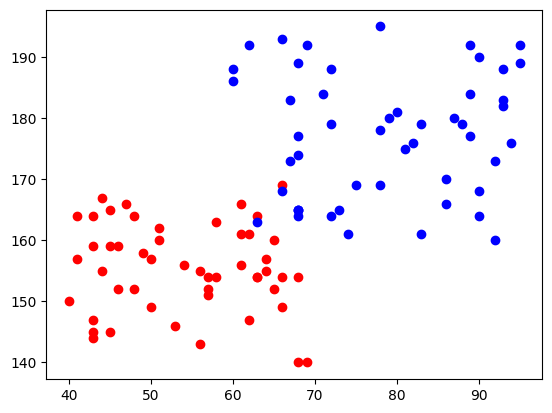

In [6]:
# print('여자 몸무게 :',[d[0] for d in data[::2]] )
# print('여자 키 :',    [d[1] for d in data[::2]] )
# print('남자 몸무게 :',[d[0] for d in data[1::2]] )
# print('남자 키 :',    [d[1] for d in data[1::2]] )
# for d in data[::2]:
#     plt.plot(d[0], d[1], 'o', color='r')
plt.plot([d[0] for d in data[::2]],
        [d[1] for d in data[::2]], 'o', color='r')
plt.plot([d[0] for d in data[1::2]],
        [d[1] for d in data[1::2]], 'o', color='b')

# 2. 군집화 로직

In [7]:
# 초기 랜덤지점 2개
random_points = [[random.randint(40, 95), random.randint(140, 195)],
                 [random.randint(40, 95), random.randint(140, 195)]]
random_points

[[91, 158], [78, 157]]

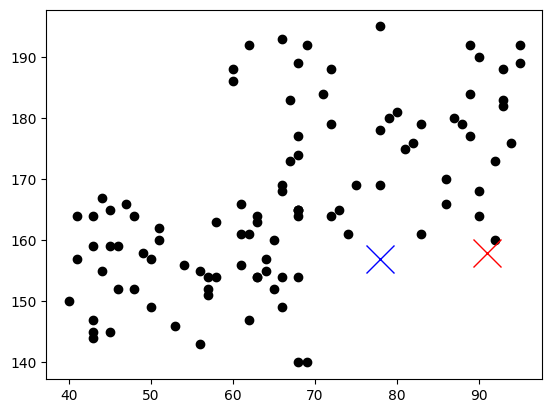

In [8]:
plt.plot([d[0] for d in data],
        [d[1] for d in data], 'o', color='k')
plt.plot(random_points[0][0], 
         random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0], 
         random_points[1][1], 'x', color='b', markersize=20) # 기준점2

In [9]:
# 두 점의 거리를 return a:(0,0) ~ b:(4,3)
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2  + (a[1]-b[1])**2 )

In [10]:
a = [1, 0]; b= [4, 3]
dist(a, b)

4.242640687119285

In [11]:
# random_points[0]과 random_points[1]을 기준으로 나눈 두 영역
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group1.append(d) # 빨간X랑 더 가까운 그룹
    else:
        group2.append(d) # 파란 X랑 더 가까운 그룹
len(group1), len(group2)

(19, 81)

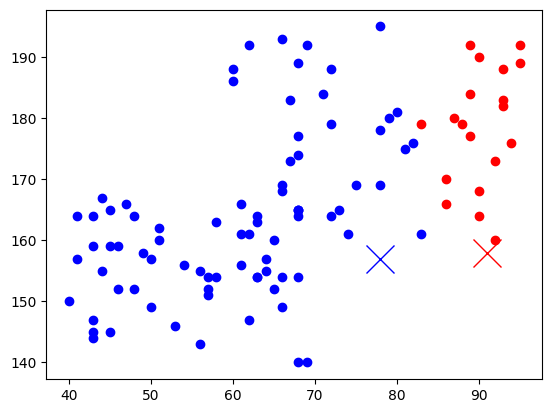

In [12]:
# 새로운 그룹 group1과 group2, 초기 램던 지점
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
        random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
        random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

In [13]:
# 기준점 이동 group1의 중심점, group2중심점
sumX=0 ; sumY=0
for g in group1:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[0] = [sumX/len(group1), sumY/len(group1)]
sumX=0 ; sumY=0
for g in group2:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[1] = [sumX/len(group2), sumY/len(group2)]
random_points

[[90.21052631578948, 178.52631578947367],
 [60.65432098765432, 163.320987654321]]

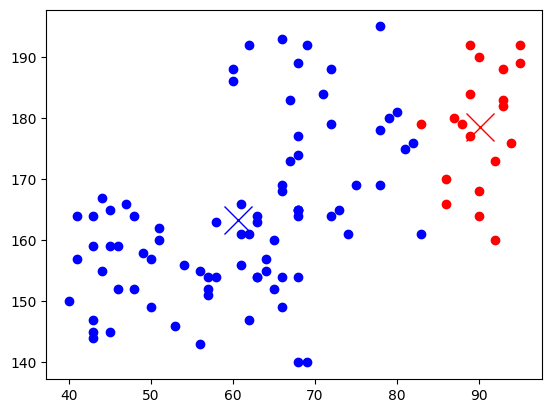

In [14]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
        random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
        random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

# 3. 전체 코드(for문이용)
- data 생성
- 랜덤포인트2지점
- for문
    - 랜덤포인트 2지점기준으로 group1과 group2
    - 랜던포인트 이용(group1중간점, group2중간점)

초기 points :  [[52, 159], [57, 177]]
1 번째 points :  [[52.26, 154.24], [78.22, 175.68]]
2 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
3 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
4 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
5 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
6 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
7 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
8 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
9 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]
10 번째 points :  [[51.125, 154.08333333333334], [78.26923076923077, 175.0]]


(140.0, 195.0)

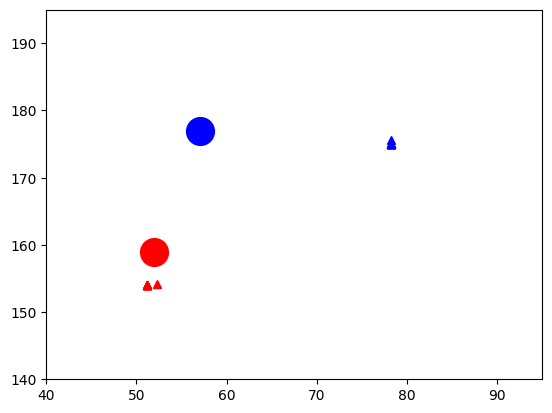

In [15]:
# 데이터 생성
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# point 지정
points = [[random.randint(40,95), random.randint(140,195)],
          [random.randint(40,95), random.randint(140,195)]]
print("초기 points : ", points)
plt.plot(points[0][0], points[0][1], 'o', c='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', c='b', markersize=20)

# 포인트 2지점기준으로 group1과 group2
for i in range(1, 11):
    group1 = [] # points[0]과 가까운 그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            group1.append(d)
        else:
            group2.append(d)
    # 새로운 포인트로 할당
    sumX = 0; sumY=0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX = 0; sumY=0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX/len(group2), sumY/len(group2)]
    print(i, "번째 points : ", points)
    plt.plot(points[0][0], points[0][1], '^', c='r')
    plt.plot(points[1][0], points[1][1], '^', c='b')
plt.xlim([40,95])
plt.ylim([140,195])

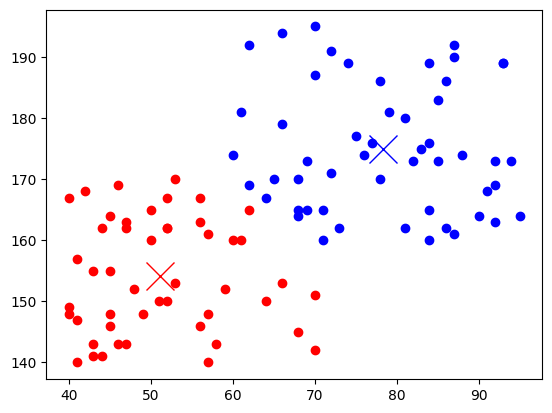

In [16]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
    - 예측모델 ; 분류, 회귀, 군집분석 fit(학습), predict(예측)
    - 변환모델 ; 전처리 ex. 스케일조정 fit(학습), transform(변환함수)

In [17]:
# 군집분석 라이브러리가 joblib충돌 경고 메세지 출력
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [18]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠
              init='random', # 초기 중심점 랜덤하게
              n_init=10, # 10번 실행
              random_state=7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [19]:
# 중심점
model.cluster_centers_

array([[ 78.26923077, 175.        ],
       [ 51.125     , 154.08333333]])

In [20]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [21]:
group1 = data[model.labels_==1]
group2 = data[model.labels_==0]
c1, c2 = model.cluster_centers_

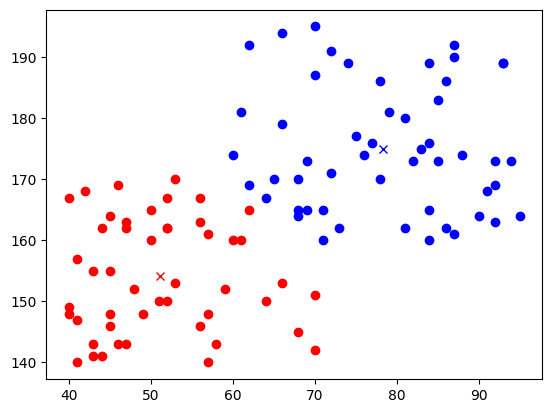

In [22]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(c1[0], c1[1], 'x', color='b') # group2의 중심점
plt.plot(c2[0], c2[1], 'x', color='r') # group1의 중심점